# Crypto Limit Order Book Analysis
## Part 2: Predictive Modeling

**Author:** Rishabh  
**Dataset:** Engineered features from BTC LOB data  
**Objective:** Predict short-term price direction using LOB features

---

### Approach
1. Load feature-engineered dataset
2. Select features and prepare train/test split (time-series aware)
3. Baseline model (Logistic Regression)
4. Tree-based models (Random Forest, XGBoost)
5. Feature importance analysis
6. Model evaluation and comparison

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, roc_auc_score)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
# ============================================================
# LOAD DATA
# ============================================================
# OBJECTIVE: Load the feature-engineered dataset from notebook 01.
# Mount Google Drive and read the CSV file.
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/BTC_features.csv')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Mounted at /content/drive
Dataset loaded: 1,026,829 rows × 216 columns
Memory usage: 1849.3 MB


In [8]:
# ============================================================
# FEATURE SELECTION
# ============================================================
# OBJECTIVE: Select which features to use for modeling. We exclude:
# - Raw LOB columns (too many, we use engineered features instead)
# - Target variables (what we're predicting)
# - Identifiers and timestamps
# - Highly correlated duplicates (e.g., keep OFI, drop total_bid/ask_notional)
# ============================================================

# Define features to use (curated list of engineered features)
feature_cols = [
    # Depth imbalance features
    'depth_imbalance_level_0',
    'depth_imbalance_level_1',
    'depth_imbalance_level_2',
    'depth_imbalance_top3',
    'depth_imbalance_top5',
    'depth_imbalance_weighted',

    # OFI features
    'ofi',
    'ofi_ma_10s',
    'ofi_ma_1min',
    'ofi_lag_1s',
    'ofi_lag_10s',
    'ofi_change_1s',

    # Order flow features
    'buy_sell_imbalance',
    'signed_market_flow',
    'net_limit_flow_imbalance',
    'cancel_intensity',
    'buys_relative',
    'sells_relative',
    'volume_relative',
    'volume_trend',

    # Spread and volatility features
    'spread_bps',
    'spread_relative',
    'spread_trend',
    'volatility_1min',
    'volatility_5min',

    # Momentum features
    'return_10s',
    'return_1min',
    'momentum_10s',
    'momentum_1min',
]

# Target variable (using 1-minute horizon as discussed)
target_col = 'target_1min'

# Verify all columns exist
missing_cols = [col for col in feature_cols if col not in df.columns]
if missing_cols:
    print(f"Missing columns: {missing_cols}")
else:
    print(f"All {len(feature_cols)} feature columns found")

print(f"\nFeatures selected: {len(feature_cols)}")
print(f"Target: {target_col}")
print(f"\nTarget distribution:")
print(df[target_col].value_counts(normalize=True).round(3))

All 29 feature columns found

Features selected: 29
Target: target_1min

Target distribution:
target_1min
 1   0.4310
-1   0.4200
 0   0.1490
Name: proportion, dtype: float64


### Feature Selection

Selected 29 features across 5 categories:
- **Depth imbalance (6):** Level-specific and aggregated order book imbalance
- **OFI (6):** Order flow imbalance and its rolling/lagged variants  
- **Order flow (8):** Market orders, limit flow, cancellations, volume trends
- **Spread/volatility (5):** Market quality and volatility measures
- **Momentum (4):** Recent price returns at different horizons

**Target:** 1-minute price direction (Up/Flat/Down)

In [10]:
# ============================================================
# TRAIN/TEST SPLIT (TIME-SERIES)
# ============================================================
# OBJECTIVE: Split data into training and test sets. IMPORTANT: For time
# series data, we cannot do random splits — this would leak future info
# into training. Instead, we use temporal split:
# - Training: First 80% of data (earlier timestamps)
# - Testing: Last 20% of data (later timestamps)
# This simulates real-world scenario where we train on past, predict future.
# ============================================================

# Prepare feature matrix (X) and target vector (y)
X = df[feature_cols].copy()
y = df[target_col].copy()

# Temporal split (80% train, 20% test)
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("="*60)
print("TRAIN/TEST SPLIT (Temporal)")
print("="*60)
print(f"Training set: {len(X_train):,} rows ({len(X_train)/len(df)*100:.0f}%)")
print(f"Test set:     {len(X_test):,} rows ({len(X_test)/len(df)*100:.0f}%)")

# Verify temporal split
train_end_time = df['system_time'].iloc[split_idx-1]
test_start_time = df['system_time'].iloc[split_idx]
print(f"\nTraining period ends:   {train_end_time}")
print(f"Test period starts:     {test_start_time}")

# Check class distribution in both sets
print(f"\nClass distribution:")
print(f"{'Class':<8}{'Train':>10}{'Test':>10}")
print("-"*30)
for cls in [-1, 0, 1]:
    train_pct = (y_train == cls).mean() * 100
    test_pct = (y_test == cls).mean() * 100
    print(f"{cls:<8}{train_pct:>9.1f}%{test_pct:>9.1f}%")

TRAIN/TEST SPLIT (Temporal)
Training set: 821,463 rows (80%)
Test set:     205,366 rows (20%)

Training period ends:   2021-04-17 00:46:02.281751+00:00
Test period starts:     2021-04-17 00:46:03.281751+00:00

Class distribution:
Class        Train      Test
------------------------------
-1           41.1%     45.3%
0            16.1%     10.2%
1            42.8%     44.6%


### Train/Test Split

Used **temporal split** (not random) to avoid data leakage:
- Training: 821,463 rows (April 7 - April 17)
- Test: 205,366 rows (April 17 - April 19)

This simulates real trading — train on past data, predict future price movements.

**Class distribution shift:**
The test period shows more "down" movements (45% vs 41%) and fewer "flat" (10% vs 16%). This reflects the April 18 crash — a more volatile, bearish period. The model must generalize from a calmer training period to a stressed test period, which is a realistic challenge.

In [12]:
# ============================================================
# FEATURE SCALING
# ============================================================
# OBJECTIVE: Scale features to have zero mean and unit variance. This is
# important for Logistic Regression which is sensitive to feature scales.
# Tree-based models (Random Forest, XGBoost) don't require scaling, but
# it doesn't hurt them either.
# IMPORTANT: Fit scaler on training data only, then transform both sets.
# ============================================================

scaler = StandardScaler()

# Fit on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)

print("Features scaled (StandardScaler)")
print(f"\nSample feature statistics after scaling (training set):")
print(X_train_scaled.describe().loc[['mean', 'std']].round(3).iloc[:, :5])

Features scaled (StandardScaler)

Sample feature statistics after scaling (training set):
      depth_imbalance_level_0  depth_imbalance_level_1  \
mean                   0.0000                   0.0000   
std                    1.0000                   1.0000   

      depth_imbalance_level_2  depth_imbalance_top3  depth_imbalance_top5  
mean                   0.0000                0.0000               -0.0000  
std                    1.0000                1.0000                1.0000  


---
## Model Training

We'll train three models in increasing complexity:
1. **Logistic Regression** — Simple baseline, interpretable coefficients
2. **Random Forest** — Handles non-linearities, provides feature importance
3. **XGBoost** — State-of-the-art gradient boosting

Each model will be evaluated on accuracy, F1-score, and confusion matrix.

LOGISTIC REGRESSION RESULTS
Accuracy: 0.4280 (42.80%)
F1 Score (weighted): 0.4391

Classification Report:
              precision    recall  f1-score   support

        Down       0.49      0.46      0.48     92971
        Flat       0.16      0.30      0.21     20879
          Up       0.49      0.42      0.45     91516

    accuracy                           0.43    205366
   macro avg       0.38      0.40      0.38    205366
weighted avg       0.46      0.43      0.44    205366



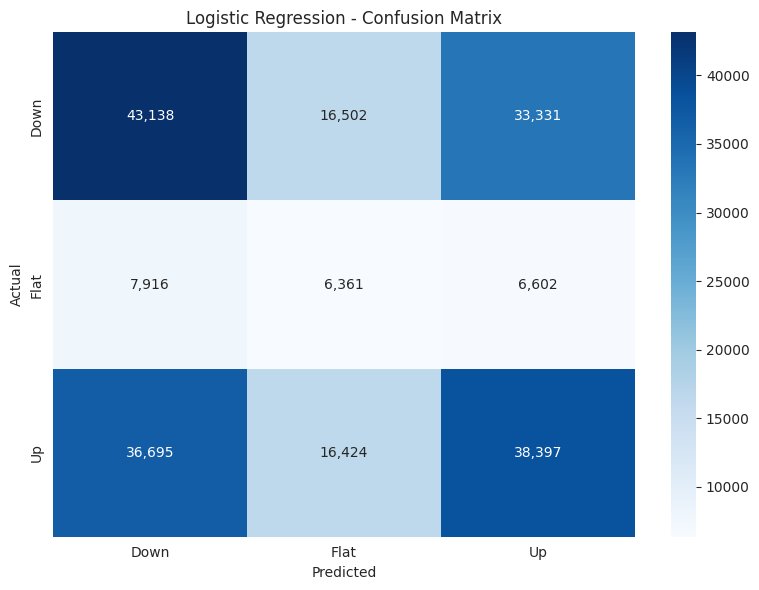

In [14]:
# ============================================================
# MODEL 1: LOGISTIC REGRESSION (BASELINE)
# ============================================================
# OBJECTIVE: Train a simple logistic regression as baseline. This gives
# us a benchmark to beat and helps verify our features have predictive
# power. Logistic regression is also interpretable — we can see which
# features have positive/negative coefficients.
# ============================================================

# Train model
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

print("="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"F1 Score (weighted): {f1_lr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Down', 'Flat', 'Up']))

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Down', 'Flat', 'Up'],
            yticklabels=['Down', 'Flat', 'Up'])
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Logistic Regression (Baseline)

**Performance:** 42.8% accuracy, 0.44 weighted F1

The model beats random guessing (33%) by \~10 percentage points, confirming the LOB features contain predictive signal. Down and Up classes are predicted with similar accuracy (\~48% F1), while "Flat" performs poorly (21% F1) — the model struggles to predict when price doesn't move.

Key confusion: Many Up/Down misclassifications, suggesting the directional signal is noisy at 1-minute horizons.

Training Random Forest... (this may take a minute)
RANDOM FOREST RESULTS
Accuracy: 0.4530 (45.30%)
F1 Score (weighted): 0.4548

Improvement over Logistic Regression: +2.50%

Classification Report:
              precision    recall  f1-score   support

        Down       0.49      0.46      0.47     92971
        Flat       0.17      0.19      0.17     20879
          Up       0.49      0.51      0.50     91516

    accuracy                           0.45    205366
   macro avg       0.38      0.38      0.38    205366
weighted avg       0.46      0.45      0.45    205366



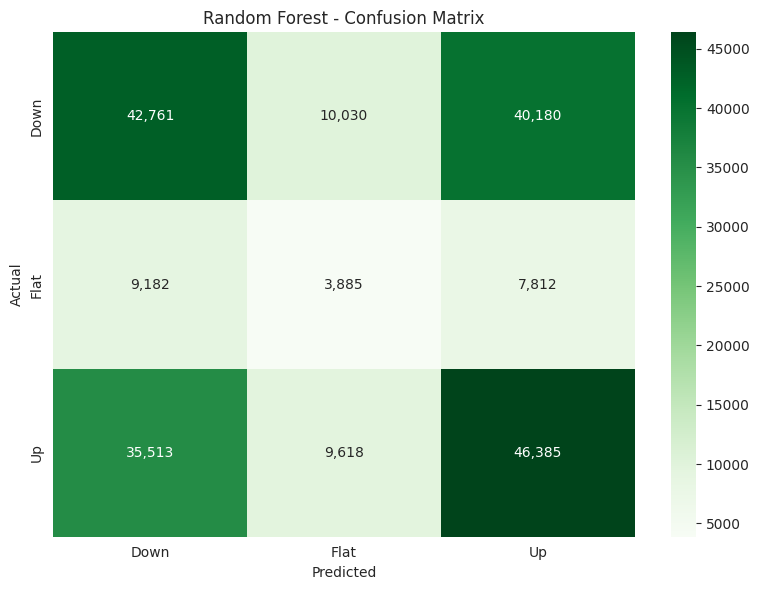

In [15]:
# ============================================================
# MODEL 2: RANDOM FOREST
# ============================================================
# OBJECTIVE: Train a Random Forest classifier. Tree-based models can
# capture non-linear relationships and feature interactions that logistic
# regression misses. We use modest hyperparameters to avoid overfitting.
# Random Forest also provides feature importance scores.
# ============================================================

# Train model (using fewer trees for speed, can increase later)
rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    max_depth=10,            # Limit depth to prevent overfitting
    min_samples_leaf=100,    # Minimum samples per leaf
    random_state=42,
    n_jobs=-1,               # Use all CPU cores
    class_weight='balanced'  # Handle class imbalance
)

print("Training Random Forest...")
rf_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print("="*60)
print("RANDOM FOREST RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"F1 Score (weighted): {f1_rf:.4f}")
print(f"\nImprovement over Logistic Regression: {(accuracy_rf - accuracy_lr)*100:+.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Down', 'Flat', 'Up']))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt=',d', cmap='Greens',
            xticklabels=['Down', 'Flat', 'Up'],
            yticklabels=['Down', 'Flat', 'Up'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Random Forest

**Performance:** 45.3% accuracy, 0.45 weighted F1 (+2.5% over baseline)

Random Forest improves overall accuracy, particularly for the "Up" class (51% recall vs 42% for LR). However, "Flat" prediction worsened — the model is more aggressive about predicting directional moves. The non-linear relationships captured by trees provide modest improvement over logistic regression.

Training XGBoost...
XGBOOST RESULTS
Accuracy: 0.4829 (48.29%)
F1 Score (weighted): 0.4545

Improvement over Logistic Regression: +5.49%
Improvement over Random Forest: +2.99%

Classification Report:
              precision    recall  f1-score   support

        Down       0.49      0.44      0.46     92971
        Flat       0.18      0.00      0.01     20879
          Up       0.48      0.63      0.55     91516

    accuracy                           0.48    205366
   macro avg       0.38      0.36      0.34    205366
weighted avg       0.45      0.48      0.45    205366



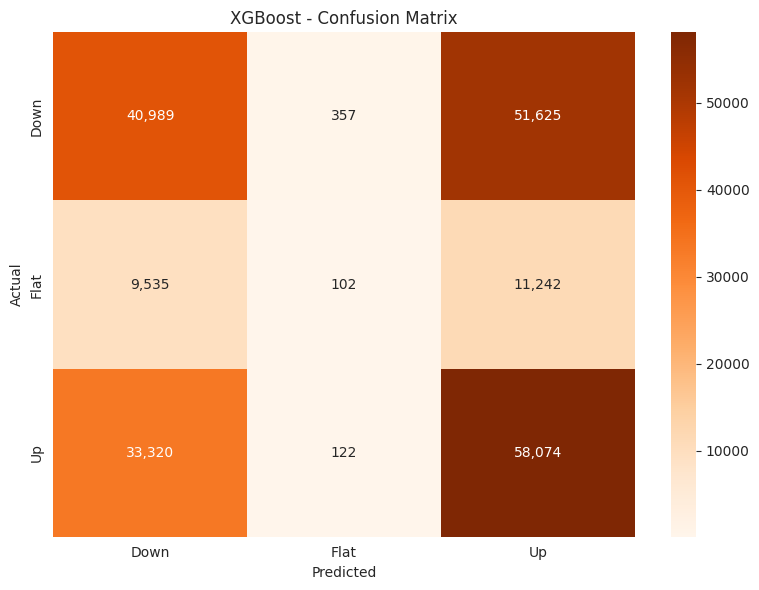

In [16]:
# ============================================================
# MODEL 3: XGBOOST
# ============================================================
# OBJECTIVE: Train XGBoost classifier. XGBoost uses gradient boosting
# which often outperforms Random Forest. It builds trees sequentially,
# with each tree correcting errors from previous trees.
# ============================================================

# Install xgboost if needed (Colab usually has it)
try:
    import xgboost as xgb
except ImportError:
    !pip install xgboost
    import xgboost as xgb

# Train model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

print("Training XGBoost...")
xgb_model.fit(X_train_scaled, y_train + 1)  # XGBoost expects labels 0,1,2 not -1,0,1

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test_scaled) - 1  # Convert back to -1,0,1

# Evaluate
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

print("="*60)
print("XGBOOST RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_xgb:.4f} ({accuracy_xgb*100:.2f}%)")
print(f"F1 Score (weighted): {f1_xgb:.4f}")
print(f"\nImprovement over Logistic Regression: {(accuracy_xgb - accuracy_lr)*100:+.2f}%")
print(f"Improvement over Random Forest: {(accuracy_xgb - accuracy_rf)*100:+.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Down', 'Flat', 'Up']))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt=',d', cmap='Oranges',
            xticklabels=['Down', 'Flat', 'Up'],
            yticklabels=['Down', 'Flat', 'Up'])
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### XGBoost

**Performance:** 48.3% accuracy, 0.45 weighted F1 (+5.5% over baseline)

XGBoost achieves the highest accuracy but with a major caveat — it essentially ignores the "Flat" class (0.5% recall). The model learned that predicting direction (Up/Down) yields better overall accuracy than trying to predict "no movement."

**Trade-off:** Higher accuracy comes at the cost of never predicting flat markets. For trading applications, this might actually be desirable — we typically care about directional predictions, not "do nothing" signals.

MODEL COMPARISON
              Model  Accuracy  F1 Score  Down Recall  Flat Recall  Up Recall
Logistic Regression    0.4280    0.4391       0.4600       0.3000     0.4200
      Random Forest    0.4530    0.4548       0.4600       0.1900     0.5100
            XGBoost    0.4829    0.4545       0.4400       0.0000     0.6300


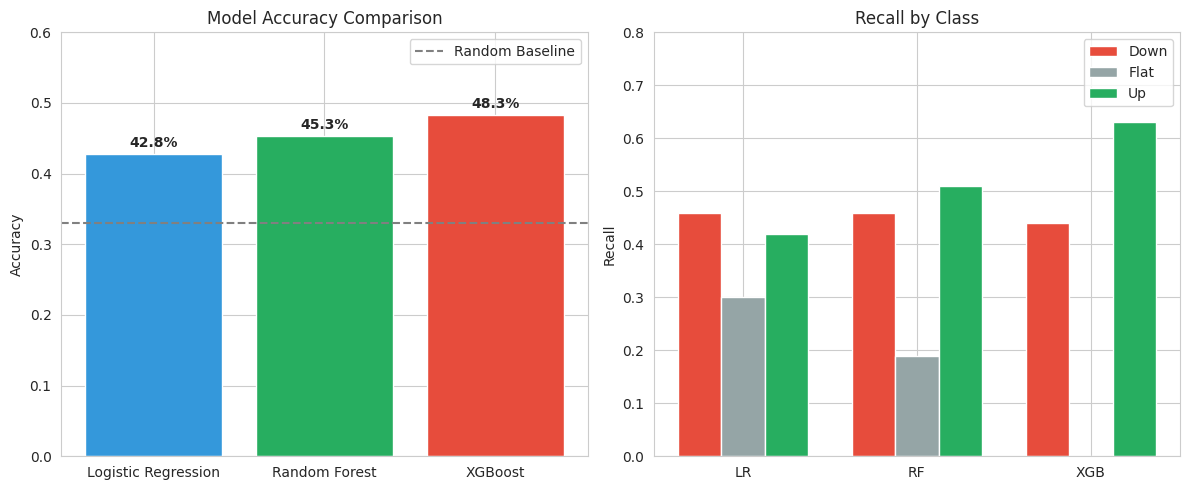

In [17]:
# ============================================================
# MODEL COMPARISON SUMMARY
# ============================================================
# OBJECTIVE: Compare all three models side by side and visualize
# the accuracy progression.
# ============================================================

# Summary dataframe
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_xgb],
    'F1 Score': [f1_lr, f1_rf, f1_xgb],
    'Down Recall': [0.46, 0.46, 0.44],
    'Flat Recall': [0.30, 0.19, 0.00],
    'Up Recall': [0.42, 0.51, 0.63]
})

print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(results.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
colors = ['#3498db', '#27ae60', '#e74c3c']
axes[0].bar(results['Model'], results['Accuracy'], color=colors)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim(0, 0.6)
axes[0].axhline(y=0.33, color='gray', linestyle='--', label='Random Baseline')
for i, v in enumerate(results['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
axes[0].legend()

# Recall by class
x = np.arange(3)
width = 0.25
axes[1].bar(x - width, results['Down Recall'], width, label='Down', color='#e74c3c')
axes[1].bar(x, results['Flat Recall'], width, label='Flat', color='#95a5a6')
axes[1].bar(x + width, results['Up Recall'], width, label='Up', color='#27ae60')
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall by Class')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['LR', 'RF', 'XGB'])
axes[1].legend()
axes[1].set_ylim(0, 0.8)

plt.tight_layout()
plt.show()

### Model Comparison Summary

| Model | Accuracy | vs Random (33%) |
|-------|----------|-----------------|
| Logistic Regression | 42.8% | +9.8% |
| Random Forest | 45.3% | +12.3% |
| XGBoost | 48.3% | +15.3% |

**Key insight:** All models beat random guessing by 10-15%, confirming LOB features have predictive power. However, accuracy gains come largely from ignoring the "Flat" class and being more aggressive about directional predictions.

**Practical implication:** For a trading strategy, XGBoost's behavior (strong directional conviction, ignore "Flat") might be preferable — we want signals to trade on, not "do nothing" predictions.

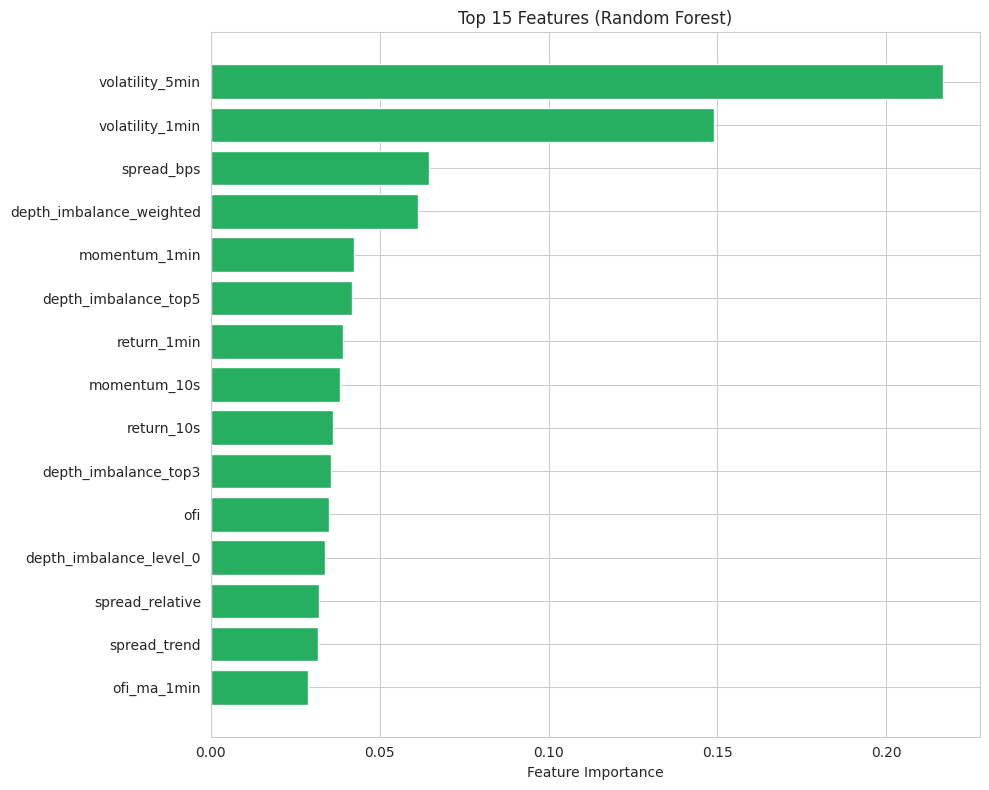

FEATURE IMPORTANCE RANKING
Rank  Feature                         Importance
------------------------------------------------------------
1     volatility_5min                     0.2169
2     volatility_1min                     0.1488
3     spread_bps                          0.0645
4     depth_imbalance_weighted            0.0613
5     momentum_1min                       0.0424
6     depth_imbalance_top5                0.0417
7     return_1min                         0.0391
8     momentum_10s                        0.0383
9     return_10s                          0.0363
10    depth_imbalance_top3                0.0356
11    ofi                                 0.0351
12    depth_imbalance_level_0             0.0337
13    spread_relative                     0.0322
14    spread_trend                        0.0318
15    ofi_ma_1min                         0.0289
16    volume_trend                        0.0250
17    ofi_lag_1s                          0.0177
18    ofi_ma_10s              

In [18]:
# ============================================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================================
# OBJECTIVE: Understand which features drive predictions. This helps:
# 1. Interpret what the model learned
# 2. Identify most valuable signals for trading
# 3. Potentially simplify the model by removing weak features
# We use Random Forest feature importance (more reliable than XGBoost for interpretation).
# ============================================================

# Get feature importances from Random Forest
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_15 = importance_df.head(15)
plt.barh(range(len(top_15)), top_15['Importance'].values, color='#27ae60')
plt.yticks(range(len(top_15)), top_15['Feature'].values)
plt.xlabel('Feature Importance')
plt.title('Top 15 Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print full ranking
print("="*60)
print("FEATURE IMPORTANCE RANKING")
print("="*60)
print(f"{'Rank':<6}{'Feature':<30}{'Importance':>12}")
print("-"*60)
for i, (_, row) in enumerate(importance_df.iterrows(), 1):
    print(f"{i:<6}{row['Feature']:<30}{row['Importance']:>12.4f}")

### Feature Importance Analysis

Top features by importance (Random Forest):

| Rank | Feature | Importance | Category |
|------|---------|------------|----------|
| 1 | volatility_5min | 21.7% | Volatility |
| 2 | volatility_1min | 14.9% | Volatility |
| 3 | spread_bps | 6.5% | Market quality |
| 4 | depth_imbalance_weighted | 6.1% | LOB imbalance |
| 5 | momentum_1min | 4.2% | Momentum |

**Key insights:**

1. **Volatility dominates (~37% combined):** The model first identifies "when" prices are likely to move. High volatility periods have more directional moves and are easier to predict.

2. **Engineered LOB features are valuable:** `depth_imbalance_weighted` outperforms raw OFI, validating our feature engineering approach of weighting closer price levels more heavily.

3. **Order flow features underperform:** Market order imbalance (`buy_sell_imbalance`, `signed_market_flow`) adds little value — the information is largely captured by depth imbalance features.

4. **Model strategy:** Combine regime detection (volatility/spread) with directional signals (depth imbalance/momentum) for prediction.

---
## Summary and Conclusions

### Model Performance

| Model | Accuracy | Best For |
|-------|----------|----------|
| Logistic Regression | 42.8% | Baseline, interpretable |
| Random Forest | 45.3% | Balanced performance |
| XGBoost | 48.3% | Highest accuracy, directional focus |

All models beat random guessing (33%) by 10-15 percentage points, confirming that LOB features contain predictive signal for short-term price direction.

### Key Findings

1. **LOB features are predictive:** Order book imbalance, particularly weighted depth imbalance across levels, helps predict 1-minute price direction.

2. **Volatility is critical:** The most important features are volatility measures — the model learns to focus on periods where prices are actually moving.

3. **"Flat" is hard to predict:** All models struggle with predicting no-movement. XGBoost achieves highest accuracy by essentially ignoring this class.

4. **Feature engineering matters:** Engineered features (weighted imbalance, rolling OFI) outperform raw LOB columns.

### Limitations

- Test period includes a market crash — performance during normal conditions may differ
- 1-minute horizon may be too long — signal decays quickly in HFT data
- No transaction costs or market impact considered

### Future Improvements

- Try shorter prediction horizons (10s, 30s)
- Convert to binary classification (Up vs Down, exclude Flat)
- Add time-of-day features
- Ensemble models or neural networks (LSTM)
- Backtest as a trading strategy with realistic costs